In [17]:
%cd ~/ASMSA/ASMSA_fork/trpcage_npy

/home/jovyan/ASMSA/ASMSA_fork/trpcage_npy


In [18]:
import os
threads = 2
os.environ['OMP_NUM_THREADS'] = str(threads)
#!pip install torchinfo
import torch
import importlib
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_num_threads(threads)
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import math
import datetime
import callbacks_py
importlib.reload(callbacks_py)
from callbacks_py import Callbacks_py

import callbacks_py_viz
importlib.reload(callbacks_py_viz)
from callbacks_py_viz import Visualizer as visualizer_py

from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset


In [19]:
def compute_number_of_neurons(layers, seed):
    neurons = []
    current_seed = seed
    for _ in range(layers):
        neurons.append(current_seed)
        current_seed //= 2
        if current_seed < 1:
            current_seed = 1
    return neurons

In [20]:
class AAEClassModel(nn.Module):
    def __init__(self, n_features, n_classes,
                 enc_layers, enc_seed,
                 disc_layers, disc_seed,
                 af=F.gelu, bn_momentum=0.2, leak_alpha=0.2,
                 latent_dim=2, dist_threshold=5.):
        super().__init__()
        self.n_classes = n_classes
        self.latent_dim = latent_dim
        self.dist_threshold2 = dist_threshold ** 2
        self.af = af
        self.leak_alpha = leak_alpha
        
        
        # ENCODER
        enc_neurons = compute_number_of_neurons(enc_layers, enc_seed)
        self.enc_layers = nn.ModuleList()
        self.enc_bn = nn.ModuleList()
        input_dim = n_features
        for n in range(enc_layers):
            self.enc_layers.append(nn.Linear(input_dim, enc_neurons[n]))
            self.enc_bn.append(nn.BatchNorm1d(enc_neurons[n], momentum=bn_momentum))
            input_dim = enc_neurons[n]
        self.latent_z = nn.Linear(input_dim, latent_dim)
        self.latent_y = nn.Linear(input_dim, n_classes)

        # CLUSTER HEADS
        self.cluster_heads = nn.Linear(n_classes, latent_dim)
        
        d = (math.pow(n_classes, 1. / latent_dim) - 1) * dist_threshold / 6.
        with torch.no_grad():
            self.cluster_heads.weight.copy_(torch.from_numpy(
                np.random.uniform(low=-d, high=d, size=(latent_dim, n_classes))
            ).float())
            self.cluster_heads.bias.copy_(torch.from_numpy(np.random.normal(size=(latent_dim,))).float())

        # DECODER
        self.dec_layers = nn.ModuleList()
        self.dec_bn = nn.ModuleList()
        input_dim = latent_dim
        for n in reversed(range(enc_layers)):
            self.dec_layers.append(nn.Linear(input_dim, enc_neurons[n]))
            self.dec_bn.append(nn.BatchNorm1d(enc_neurons[n], momentum=bn_momentum))
            input_dim = enc_neurons[n]
        self.dec_out = nn.Linear(input_dim, n_features)

        # DISCRIMINATORS
        disc_neurons = compute_number_of_neurons(disc_layers, disc_seed)
        self.y_disc_layers = nn.ModuleList()
        self.z_disc_layers = nn.ModuleList()
        input_y = n_classes
        input_z = latent_dim
        for n in range(disc_layers):
            self.y_disc_layers.append(nn.Linear(input_y, disc_neurons[n]))
            self.z_disc_layers.append(nn.Linear(input_z, disc_neurons[n]))
            input_y = disc_neurons[n]
            input_z = disc_neurons[n]
        self.y_disc_out = nn.Linear(input_y, 1)
        self.z_disc_out = nn.Linear(input_z, 1)

        # OPTIMIZER/LOSSES
        self.ae_loss_fn = nn.HuberLoss()
        self.optimizer = None # Defined in compile()

    # HELPER FUNCTIONS FOR PARAMETER GROUPS
    def _get_encoder_weights(self):
        """Returns parameters belonging to the Encoder"""
        linear_params = sum([list(l.parameters()) for l in self.enc_layers], [])
        latent_params = list(self.latent_y.parameters()) + list(self.latent_z.parameters())
        bn_params = sum([list(bn.parameters()) for bn in self.enc_bn], [])
        return linear_params + latent_params + bn_params
        
    def _get_y_disc_weights(self):
        """Returns parameters belonging to the Categorical Discriminator"""
        return sum([list(l.parameters()) for l in self.y_disc_layers], []) + list(self.y_disc_out.parameters())
    
    def _get_z_disc_weights(self):
        """Returns parameters belonging to the Continuous Discriminator"""
        return sum([list(l.parameters()) for l in self.z_disc_layers], []) + list(self.z_disc_out.parameters())
    
    def _get_cluster_head_weights(self):
        """Returns parameters belonging to the Cluster Heads"""
        return list(self.cluster_heads.parameters())

    def _get_ae_weights(self):
        """Returns all Autoencoder related parameters: E + D + H"""
        enc_params = self._get_encoder_weights()
        dec_linear_params = sum([list(l.parameters()) for l in self.dec_layers], [])
        dec_bn_params = sum([list(bn.parameters()) for bn in self.dec_bn], [])
        dec_out_params = list(self.dec_out.parameters())
        head_params = self._get_cluster_head_weights()
        return enc_params + dec_linear_params + dec_bn_params + dec_out_params + head_params

    def encode(self, x):
        """Encoder forward pass"""
        out = x
        for l, bn in zip(self.enc_layers, self.enc_bn):
            out = bn(self.af(l(out)))
        y = F.softmax(self.latent_y(out), dim=1)
        z = self.latent_z(out)
        hz = self.cluster_heads(y)
        latent = z + hz
        return y, z, latent

    def decode(self, latent):
        """Decoder forward pass"""
        out = latent
        for l, bn in zip(self.dec_layers, self.dec_bn):
            out = bn(self.af(l(out)))
        return self.dec_out(out)

    def y_discriminator(self, y):
        """Categorical Discriminator forward pass"""
        out = y
        for l in self.y_disc_layers:
            out = F.leaky_relu(l(out), negative_slope=self.leak_alpha)
        return self.y_disc_out(out)

    def z_discriminator(self, z):
        """Continuous Discriminator forward pass"""
        out = z
        for l in self.z_disc_layers:
            out = F.leaky_relu(l(out), negative_slope=self.leak_alpha)
        return self.z_disc_out(out)

    def forward(self, x):
        """Full model forward pass for inference/testing"""
        y, z, latent = self.encode(x)
        rec = self.decode(latent)
        return rec, y, z, latent

    def compile(self, lr=1e-4, wd=1e-5, betas=(0.9, 0.999)):
        """Sets up the SINGLE AdamW optimizer for all trainable parameters"""
        self.optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=lr,
            weight_decay=wd,
            betas=betas
        )

    # TRAIN_STEP METHOD
    def train_step(self, x):
        """
        Performs a single training step consisting of 6 isolated updates.
        Uses a SINGLE optimizer instance applied selectively to parameter groups.
        """
        self.train()
        device = next(self.parameters()).device
        if isinstance(x, (tuple, list)):
            x = x[0]
        x = x.to(device)
        losses = {}
        
        # Define parameter groups
        encoder_weights = self._get_encoder_weights()
        ae_all_weights = self._get_ae_weights()
        y_disc_weights = self._get_y_disc_weights()
        z_disc_weights = self._get_z_disc_weights()
        cluster_head_weights = self._get_cluster_head_weights()

        #  AUTOENCODER UPDATE (Updates Enc/Dec/Heads)
        self.optimizer.zero_grad(set_to_none=True)
        y_enc, z_enc, latent = self.encode(x)
        rec = self.decode(latent)
        ael = self.ae_loss_fn(rec, x)
        
        y_enc_detached = y_enc.detach()
        z_enc_detached = z_enc.detach()
        
        # Apply gradients only to AE weights
        ael.backward(inputs=ae_all_weights)
        self.optimizer.step()
        losses['ae_loss'] = ael.item()

        # CATEGORICAL DISCRIMINATOR UPDATE (Updates Y-Disc)
        self.optimizer.zero_grad(set_to_none=True)
        idx = torch.randint(0, self.n_classes, (x.size(0),), device=device)
        randy = F.one_hot(idx, self.n_classes).float()
        
        y_real_pred = self.y_discriminator(randy)
        y_fake_pred = self.y_discriminator(y_enc_detached)
        
        y_real_pred = y_real_pred * (torch.rand_like(y_real_pred) * 0.05 + 1.0)
        y_fake_pred = y_fake_pred * (torch.rand_like(y_fake_pred) * 0.05 + 1.0)
        y_disc_loss = (y_fake_pred.mean() - y_real_pred.mean()) * 1e-5
        
        # Apply gradients only to Y-Disc weights
        y_disc_loss.backward(inputs=y_disc_weights)
        self.optimizer.step()
        losses['y_disc_loss'] = y_disc_loss.item()

        # Y CHEAT (ENCODER) UPDATE (Updates Enc)
        self.optimizer.zero_grad(set_to_none=True)
        
        # RERUN ENCODE
        y_enc_new, _, _ = self.encode(x)
        
        yc = self.y_discriminator(y_enc_new)
        yc = yc * (torch.rand_like(yc) * 0.05 + 1.0)
        y_cheat_loss = -yc.mean() * 1e-5
        
        # Apply gradients only to Encoder weights
        y_cheat_loss.backward(inputs=encoder_weights)
        self.optimizer.step()
        losses['y_cheat_loss'] = y_cheat_loss.item()
        
        # CONTINUOUS DISCRIMINATOR  UPDATE (Updates Z-Disc)
        self.optimizer.zero_grad(set_to_none=True)
        randz = torch.empty(x.size(0), self.latent_dim, device=device).uniform_(-1, 1)
        
        nzp = self.z_discriminator(z_enc_detached)
        pzp = self.z_discriminator(randz)
        
        nzp = nzp * (torch.rand_like(nzp) * 0.05 + 1.0)
        pzp = pzp * (torch.rand_like(pzp) * 0.05 + 1.0)
        z_disc_loss = (nzp.mean() - pzp.mean()) #*1e-5
        
        # Apply gradients only to Z-Disc weights
        z_disc_loss.backward(inputs=z_disc_weights)
        self.optimizer.step()
        losses['z_disc_loss'] = z_disc_loss.item()
        
        # Z CHEAT (ENCODER) UPDATE (Updates Enc)
        self.optimizer.zero_grad(set_to_none=True)
        
        # RERUN ENCOD
        _, z_enc_new, _ = self.encode(x)
        
        zc = self.z_discriminator(z_enc_new)
        zc = zc * (torch.rand_like(zc) * 0.05 + 1.0) 
        z_cheat_loss = -zc.mean() #*1e-5
        
        # Apply gradients only to Encoder weights
        z_cheat_loss.backward(inputs=encoder_weights)
        self.optimizer.step()
        losses['z_cheat_loss'] = z_cheat_loss.item()
        
        # CLUSTER HEAD UPDATE (Updates Heads)
        self.optimizer.zero_grad(set_to_none=True)
        randc = torch.diag(torch.rand(self.n_classes, device=device) * 0.1 + 0.95)
        ch = self.cluster_heads(randc)
        
        norms = torch.sum(ch ** 2, dim=1, keepdim=True)
        dists_squared = norms - 2 * ch @ ch.T + norms.T
        
        mask = dists_squared < self.dist_threshold2
        
        dists_squared = torch.clamp(dists_squared, min=0.0) 

        hl = torch.exp(-dists_squared)[mask].sum() / (self.dist_threshold2 * self.n_classes ** 2) * 21.0

        # Apply gradients only to Cluster Head weights
        hl.backward(inputs=cluster_head_weights)
        self.optimizer.step()
        losses['cluster_head_loss'] = hl.item()
        
        return losses

    # TEST_STEP METHOD
    def test_step(self, x):
        """Performs a single evaluation step."""
        self.eval()
        with torch.no_grad():
            if isinstance(x, (tuple, list)):
                x = x[0]
            x = x.to(next(self.parameters()).device)
            device = x.device

            y, z, latent = self.encode(x)
            rec = self.decode(latent)
            val_ae_loss = self.ae_loss_fn(rec, x)

            # Y-Disc losses
            idx = torch.randint(0, self.n_classes, (x.size(0),), device=device)
            randy = F.one_hot(idx, self.n_classes).float()
            
            nyp = self.y_discriminator(y)
            pyp = self.y_discriminator(randy)
            val_y_disc_loss = (nyp.mean() - pyp.mean()) * 1e-5
            val_y_cheat_loss = -nyp.mean() * 1e-5

            # Z-Disc losses
            randz = torch.randn(x.size(0), self.latent_dim, device=device)
            nzp = self.z_discriminator(z)
            pzp = self.z_discriminator(randz)
            val_z_disc_loss = (nzp.mean() - pzp.mean())#* 1e-5
            val_z_cheat_loss = -nzp.mean()#* 1e-5

            # Cluster head validation loss (FIX APPLIED HERE TOO)
            randc = torch.diag(torch.ones(self.n_classes, device=device))
            ch = self.cluster_heads(randc)
            norms = torch.sum(ch ** 2, dim=1, keepdim=True)
            dists_squared = norms - 2 * ch @ ch.T + norms.T
            
            mask = dists_squared < self.dist_threshold2
            dists_squared = torch.clamp(dists_squared, min=0.0)

            val_cluster_head_loss = torch.exp(-dists_squared)[mask].sum() / (self.dist_threshold2 * self.n_classes ** 2) * 21.0

        self.train()
        return {
            'ae_loss': val_ae_loss.item(),
            'y_disc_loss': val_y_disc_loss.item(),
            'y_cheat_loss': val_y_cheat_loss.item(),
            'z_disc_loss': val_z_disc_loss.item(),
            'z_cheat_loss': val_z_cheat_loss.item(),
            'cluster_head_loss': val_cluster_head_loss.item()
        }

    def call(self, x):
        """Inference function to get the latent representation"""
        self.eval()
        with torch.no_grad():
            _, _, latent = self.encode(x.to(next(self.parameters()).device))
        return latent


In [21]:
# XXX: essential hps manually
batch_size = 64
best_enc_seed=128
best_disc_seed=128 
ae_layers=2 
disc_layers=3
#learning_rate=0.00002
#n_classes = 40

## weaken discriminators
#best_disc_seed=64
#disc_layers=2
#learning_rate=0.00002
n_classes = 8 # 16 # 4
n_classes = 4

# weird experiments
# best_disc_seed=32

In [22]:
# DATA LOADERS
X_train_np = np.load('datasets/intcoords/train.npy')
X_train_tensor = torch.from_numpy(X_train_np).float()
train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

X_test_np = np.load('datasets/intcoords/test.npy')
X_test_tensor = torch.from_numpy(X_test_np).float()

X_test_batched = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size, shuffle=False)

X_val_np = np.load('datasets/intcoords/validate.npy')
X_val_tensor = torch.from_numpy(X_val_np).float()
val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)

In [23]:
m = AAEClassModel(
    n_features=X_train_np.shape[1],
    n_classes=n_classes,
    enc_layers=ae_layers,
    enc_seed=best_enc_seed,
    disc_layers=disc_layers,
    disc_seed=best_disc_seed
)
m.compile()
log_dir = "logs/class_traom/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

cb_manager = Callbacks_py(
    model=m, 
    log_dir=log_dir, 
    inputs=X_test_tensor, 
    freq=20, 
    monitor="val_ae_loss"
)

In [24]:
# HELPER FUNCTIONS
def train_one_epoch(model, loader):
    m.train()
    epoch_outputs = []
    for batch in loader:
        data = batch[0]
        step_losses = model.train_step(data)
        epoch_outputs.append(step_losses)
    keys = epoch_outputs[0].keys()
    return {k: np.mean([x[k] for x in epoch_outputs]) for k in keys}

def validate(model, loader):
    m.eval()
    epoch_outputs = []
    with torch.no_grad():
        for batch in loader:
            data = batch[0]
            step_losses = model.test_step(data)
            epoch_outputs.append(step_losses)
    keys = epoch_outputs[0].keys()
    return {f"val_{k}": np.mean([x[k] for x in epoch_outputs]) for k in keys}



Epoch: 1/200
487/487 - 5s - loss: 0.3898 - y_disc_loss: -4.0821e-06 - y_cheat_loss: 9.9556e-07 - z_disc_loss: -3.3859e-03 - z_cheat_loss: 0.1205 - cluster_head_loss: 0.5099 - val_loss: 0.3481 - val_y_disc_loss: -1.6381e-05 - val_y_cheat_loss: 4.3308e-06 - val_z_disc_loss: 0.0163 - val_z_cheat_loss: 0.1320 - val_cluster_head_loss: 0.4849 - lr: 1.0000e-04
Epoch: 2/200
487/487 - 5s - loss: 0.3619 - y_disc_loss: -1.4634e-04 - y_cheat_loss: 6.5001e-05 - z_disc_loss: 8.5325e-04 - z_cheat_loss: 0.1321 - cluster_head_loss: 0.4587 - val_loss: 0.3392 - val_y_disc_loss: -3.3373e-04 - val_y_cheat_loss: 1.1801e-04 - val_z_disc_loss: 0.0416 - val_z_cheat_loss: 0.1609 - val_cluster_head_loss: 0.4326 - lr: 1.0000e-04
Epoch: 3/200
487/487 - 5s - loss: 0.3577 - y_disc_loss: -9.7532e-04 - y_cheat_loss: 4.1328e-04 - z_disc_loss: 8.3578e-04 - z_cheat_loss: 0.0964 - cluster_head_loss: 0.4085 - val_loss: 0.3390 - val_y_disc_loss: -1.4325e-03 - val_y_cheat_loss: 4.1828e-04 - val_z_disc_loss: -2.5286e-02 - val

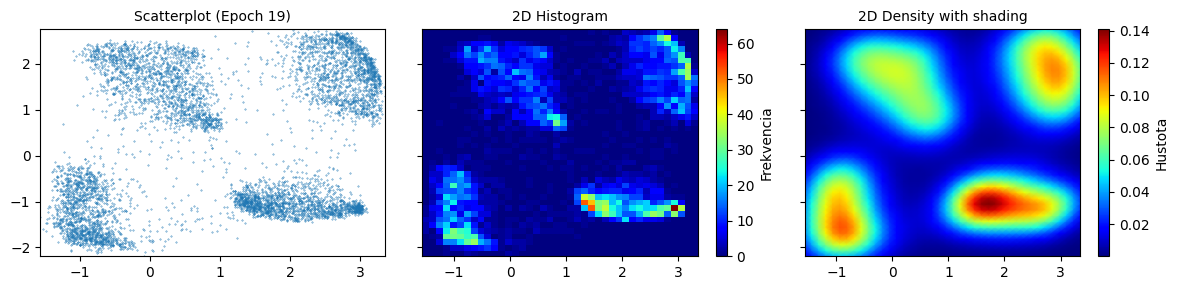

Epoch: 20/200
487/487 - 5s - loss: 0.3509 - y_disc_loss: -3.1938e-03 - y_cheat_loss: -4.0940e-02 - z_disc_loss: -2.9673e-03 - z_cheat_loss: -2.8330e-01 - cluster_head_loss: 0.2109 - val_loss: 0.3282 - val_y_disc_loss: -3.8276e-03 - val_y_cheat_loss: -4.0397e-02 - val_z_disc_loss: 0.1044 - val_z_cheat_loss: 0.1286 - val_cluster_head_loss: 0.2107 - lr: 1.0000e-04
Epoch: 21/200
487/487 - 5s - loss: 0.3501 - y_disc_loss: -3.3593e-03 - y_cheat_loss: -4.3560e-02 - z_disc_loss: -1.0274e-03 - z_cheat_loss: 0.2086 - cluster_head_loss: 0.2107 - val_loss: 0.3286 - val_y_disc_loss: -4.4668e-03 - val_y_cheat_loss: -4.2405e-02 - val_z_disc_loss: -6.1642e-02 - val_z_cheat_loss: 0.1811 - val_cluster_head_loss: 0.2106 - lr: 1.0000e-04
Epoch: 22/200
487/487 - 5s - loss: 0.3505 - y_disc_loss: -3.5149e-03 - y_cheat_loss: -4.7073e-02 - z_disc_loss: 0.0034 - z_cheat_loss: 0.3070 - cluster_head_loss: 0.2105 - val_loss: 0.3327 - val_y_disc_loss: -3.0966e-03 - val_y_cheat_loss: -4.7220e-02 - val_z_disc_loss: 0

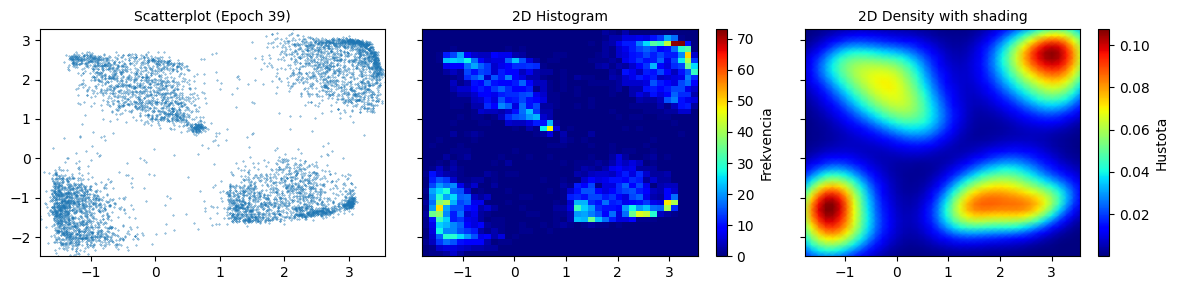

Epoch: 40/200
487/487 - 5s - loss: 0.3476 - y_disc_loss: -3.8538e-03 - y_cheat_loss: -8.4145e-02 - z_disc_loss: 0.0145 - z_cheat_loss: 0.0858 - cluster_head_loss: 0.2101 - val_loss: 0.3252 - val_y_disc_loss: -3.0805e-03 - val_y_cheat_loss: -8.4240e-02 - val_z_disc_loss: -1.1576e-01 - val_z_cheat_loss: 0.0651 - val_cluster_head_loss: 0.2101 - lr: 5.0000e-05
Epoch: 41/200
487/487 - 5s - loss: 0.3475 - y_disc_loss: -3.7350e-03 - y_cheat_loss: -8.7038e-02 - z_disc_loss: 0.0247 - z_cheat_loss: -5.1217e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3254 - val_y_disc_loss: -2.9108e-03 - val_y_cheat_loss: -8.6776e-02 - val_z_disc_loss: 0.0033 - val_z_cheat_loss: 0.2804 - val_cluster_head_loss: 0.2101 - lr: 5.0000e-05
Epoch: 42/200
487/487 - 5s - loss: 0.3471 - y_disc_loss: -3.7842e-03 - y_cheat_loss: -8.8778e-02 - z_disc_loss: 0.0166 - z_cheat_loss: 0.2122 - cluster_head_loss: 0.2101 - val_loss: 0.3264 - val_y_disc_loss: -2.3900e-03 - val_y_cheat_loss: -8.8884e-02 - val_z_disc_loss: 0.0233 - va

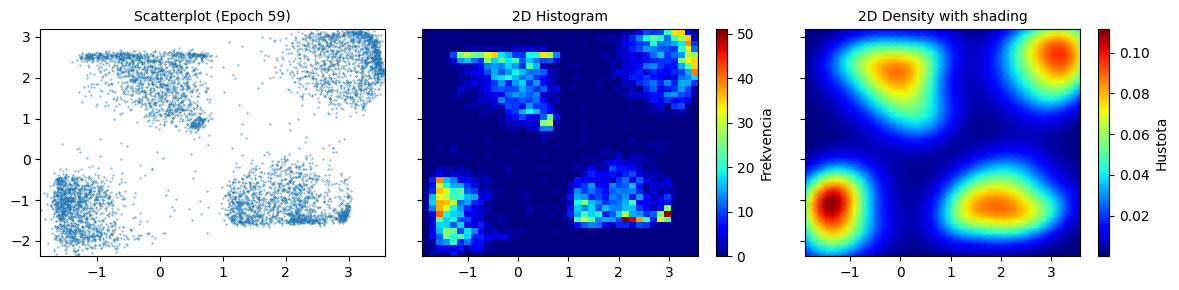

Epoch: 60/200
487/487 - 5s - loss: 0.3461 - y_disc_loss: -4.1752e-03 - y_cheat_loss: -1.1244e-01 - z_disc_loss: 0.0102 - z_cheat_loss: 0.0895 - cluster_head_loss: 0.2101 - val_loss: 0.3236 - val_y_disc_loss: -5.8217e-03 - val_y_cheat_loss: -1.0849e-01 - val_z_disc_loss: 0.0311 - val_z_cheat_loss: 0.0168 - val_cluster_head_loss: 0.2101 - lr: 2.5000e-05
Epoch: 61/200
487/487 - 5s - loss: 0.3460 - y_disc_loss: -4.0169e-03 - y_cheat_loss: -1.1414e-01 - z_disc_loss: 0.0066 - z_cheat_loss: -1.2721e-01 - cluster_head_loss: 0.2101 - val_loss: 0.3235 - val_y_disc_loss: -6.0532e-03 - val_y_cheat_loss: -1.1001e-01 - val_z_disc_loss: 0.1020 - val_z_cheat_loss: 0.0166 - val_cluster_head_loss: 0.2101 - lr: 2.5000e-05
Epoch: 62/200
487/487 - 5s - loss: 0.3462 - y_disc_loss: -4.2139e-03 - y_cheat_loss: -1.1538e-01 - z_disc_loss: -5.7021e-03 - z_cheat_loss: 0.1439 - cluster_head_loss: 0.2101 - val_loss: 0.3246 - val_y_disc_loss: -5.8297e-03 - val_y_cheat_loss: -1.1126e-01 - val_z_disc_loss: 0.2008 - va

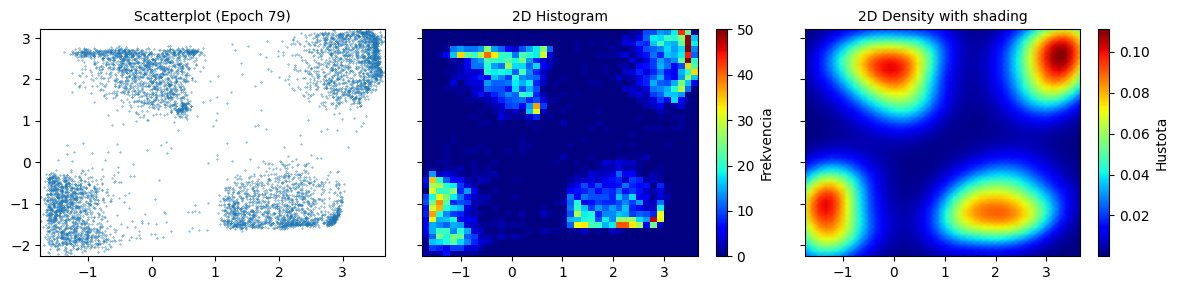

Epoch: 80/200
487/487 - 5s - loss: 0.3458 - y_disc_loss: -4.2398e-03 - y_cheat_loss: -1.2461e-01 - z_disc_loss: 0.0059 - z_cheat_loss: -6.7094e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3234 - val_y_disc_loss: -5.1179e-03 - val_y_cheat_loss: -1.2099e-01 - val_z_disc_loss: 0.1356 - val_z_cheat_loss: 0.0055 - val_cluster_head_loss: 0.2101 - lr: 1.2500e-05
Epoch: 81/200
487/487 - 5s - loss: 0.3455 - y_disc_loss: -3.8718e-03 - y_cheat_loss: -1.2576e-01 - z_disc_loss: -2.7112e-03 - z_cheat_loss: 0.0487 - cluster_head_loss: 0.2101 - val_loss: 0.3234 - val_y_disc_loss: -4.9476e-03 - val_y_cheat_loss: -1.2179e-01 - val_z_disc_loss: 0.1893 - val_z_cheat_loss: -4.3789e-02 - val_cluster_head_loss: 0.2101 - lr: 1.2500e-05

[LR] Zníženie na 6.25e-06
Epoch: 82/200
487/487 - 5s - loss: 0.3456 - y_disc_loss: -3.7805e-03 - y_cheat_loss: -1.2646e-01 - z_disc_loss: 0.0154 - z_cheat_loss: -2.0995e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3232 - val_y_disc_loss: -5.1623e-03 - val_y_cheat_loss: -1.22

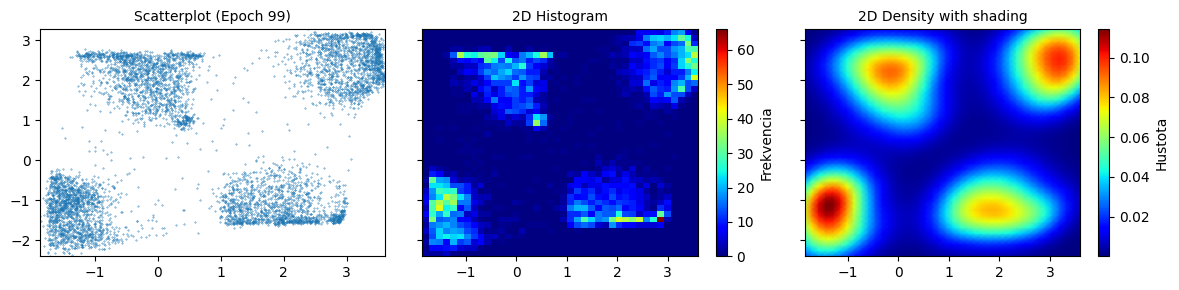

Epoch: 100/200
487/487 - 5s - loss: 0.3454 - y_disc_loss: -4.2643e-03 - y_cheat_loss: -1.3465e-01 - z_disc_loss: 9.7598e-04 - z_cheat_loss: -9.3867e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3239 - val_y_disc_loss: -4.7019e-03 - val_y_cheat_loss: -1.3096e-01 - val_z_disc_loss: 0.1206 - val_z_cheat_loss: -6.2630e-02 - val_cluster_head_loss: 0.2101 - lr: 6.2500e-06
Epoch: 101/200
487/487 - 5s - loss: 0.3454 - y_disc_loss: -4.1780e-03 - y_cheat_loss: -1.3515e-01 - z_disc_loss: -1.6794e-03 - z_cheat_loss: -5.3485e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3232 - val_y_disc_loss: -4.6893e-03 - val_y_cheat_loss: -1.3163e-01 - val_z_disc_loss: 0.1483 - val_z_cheat_loss: -5.6500e-02 - val_cluster_head_loss: 0.2101 - lr: 6.2500e-06

[LR] Zníženie na 3.125e-06
Epoch: 102/200
487/487 - 5s - loss: 0.3453 - y_disc_loss: -4.2702e-03 - y_cheat_loss: -1.3553e-01 - z_disc_loss: 2.7239e-04 - z_cheat_loss: -3.9916e-02 - cluster_head_loss: 0.2101 - val_loss: 0.3234 - val_y_disc_loss: -5.0865e-03 - v

In [25]:
import pkbar
import time

# TRAINING LOOP
epochs = 200
num_batches = len(train_loader)

for epoch in range(1, epochs + 1):
    kbar = pkbar.Kbar(target=num_batches, epoch=epoch-1, num_epochs=epochs, width=30, verbose=2)
    
    m.train()
    epoch_outputs = []
    
    for i, batch in enumerate(train_loader):
        data = batch[0]
        step_losses = m.train_step(data)
        epoch_outputs.append(step_losses)
        
        kbar.update(i, values=[("loss", step_losses['ae_loss'])])
    
    train_logs = {k: np.mean([x[k] for x in epoch_outputs]) for k in epoch_outputs[0].keys()}
    
    val_logs = validate(m, val_loader)
    
    final_values = [("loss", train_logs['ae_loss'])] # 'loss' na začiatok
    
    for k, v in train_logs.items():
        if k != 'ae_loss': # aby sme ich nemali dvakrát
            final_values.append((k, v))
            
    final_values.append(("val_loss", val_logs['val_ae_loss']))
    for k, v in val_logs.items():
        if k != 'val_ae_loss':
            final_values.append((k, v))
            
    current_lr = m.optimizer.param_groups[0]['lr']
    final_values.append(("lr", current_lr))

    kbar.add(1, values=final_values)

    all_logs = {**train_logs, **val_logs, 'lr': current_lr}
    should_stop = cb_manager.on_epoch_end(epoch, all_logs)
    
    if should_stop:
        print(f"Early stopping at epoch {epoch}")
        break

/home/jovyan/ASMSA/ASMSA_fork/callbacks_py_viz.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  # 1. Scatterplot


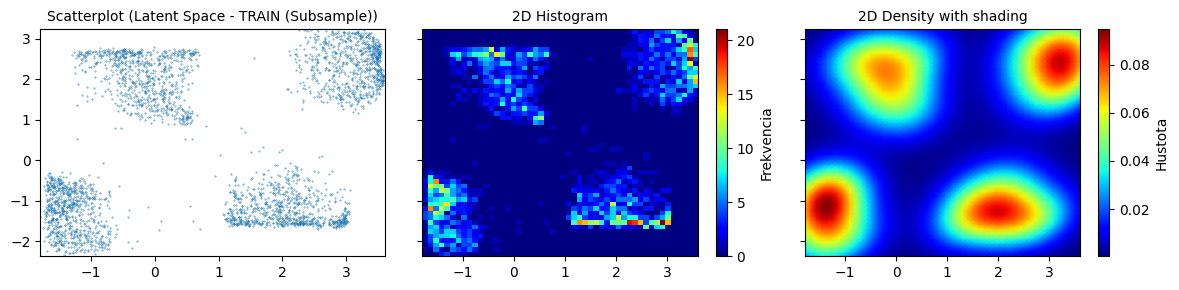

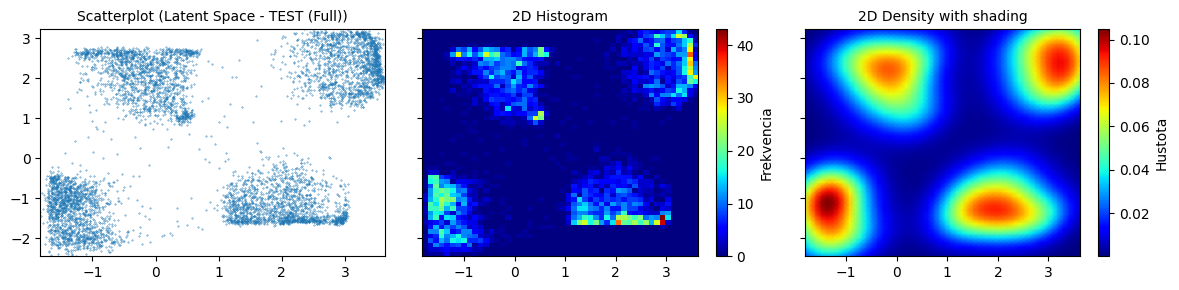

In [26]:
from callbacks_py_viz import Visualizer
import torch

viz = Visualizer(figsize=(12, 3), nbins=50)
m.eval()
device = next(m.parameters()).device

with torch.no_grad():
    # TRAIN VIZ
    X_train_tensor = torch.from_numpy(X_train_np[::10,:]).float().to(device)
    latent_train = m(X_train_tensor)[3]
    viz.make_visualization(latent_train, title="Latent Space - TRAIN (Subsample)")

    # TEST VIZ
    X_test_tensor = torch.from_numpy(X_test_np).float().to(device)
    latent_test = m(X_test_tensor)[3]
    viz.make_visualization(latent_test, title="Latent Space - TEST (Full)")

In [ ]:
m.summary()

In [ ]:
import tf2onnx
import onnx2torch
import tempfile

def _convert_to_onnx(model, destination_path):
    input_tensor = model.layers[0]._input_tensor
    input_signature = tf.TensorSpec(
        name=input_tensor.name, shape=input_tensor.shape, dtype=input_tensor.dtype
    )
    output_name = model.layers[-1].name

    @tf.function(input_signature=[input_signature])
    def _wrapped_model(input_data):
        return {output_name: model(input_data)}

    tf2onnx.convert.from_function(
        _wrapped_model, input_signature=[input_signature], output_path=destination_path
    )

In [ ]:
with tempfile.NamedTemporaryFile() as onnx:
    _convert_to_onnx(m.sumenc,onnx.name)
    torch_enc = onnx2torch.convert(onnx.name)

example_input = torch.randn([X_train_np.shape[1]])
traced_script_module = torch.jit.trace(torch_enc, example_input)

traced_script_module.save('encoder.pt')

In [ ]:
lenc = torch.jit.load('encoder.pt')
example_input = np.random.rand(10000,X_train_np.shape[1])
rtf = m.sumenc(example_input)
rpt = lenc(torch.tensor(example_input,dtype=torch.float32))

In [ ]:
maxerr = np.max(np.abs(rtf - rpt.detach().numpy()))
maxerr

In [ ]:
lowsk = m.sumenc(X_test_np)
lowsp = lenc(torch.tensor(X_test_np,dtype=torch.float32))
lowsk.shape, lowsp.shape

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lowsk[:,0],lowsk[:,1])
plt.subplot(122)
plt.scatter(lowsp[:,0],lowsp[:,1])
plt.show()

In [ ]:
with tempfile.NamedTemporaryFile() as onnx:
    _convert_to_onnx(m.dec,onnx.name)
    torch_dec = onnx2torch.convert(onnx.name)

example_input = torch.randn([2])
traced_script_module = torch.jit.trace(torch_dec, example_input)

traced_script_module.save('decoder-unif.pt')

In [ ]:
ldec = torch.jit.load('decoder-unif.pt')
example_input = np.random.rand(10000,2)
rtf = m.dec(example_input)
rpt = ldec(torch.tensor(example_input,dtype=torch.float32))

In [ ]:
err = np.abs(rtf - rpt.detach().numpy())
train_mean = np.loadtxt('datasets/intcoords/mean.txt',dtype=np.float32).reshape(1,1,-1)
rerr = err/np.abs(train_mean)
np.max(err),np.max(rerr)

In [ ]:
tr = md.load('../DE-Shaw/trpcage_red.xtc',top=conf)

In [ ]:
# load all dataset
X_all = tf.data.Dataset.load('datasets/intcoords/X_all')

# get batched version of dataset to feed to AAE model for prediction
X_all_batched = X_all.batch(batch_size,drop_remainder=True)

# get numpy version for testing purposes
X_all_np = np.stack(list(X_all))
X_all_np.shape

In [ ]:
tica = np.load("tica.npy")

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1) #tica[:,1]
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1) #tica[:,1]
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
traj = md.load_xtc("../DE-Shaw/trpcage_red.xtc", top=conf)

dssp = md.compute_dssp(traj, simplified=True)  # simplified=True → 'H' (alpha helix), 'E' (beta sheet), etc.

alpha_content_per_frame = np.mean(dssp == 'H', axis=1)

average_alpha_helix_content = np.mean(alpha_content_per_frame)

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=alpha_content_per_frame,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("alpha_content")

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=tica[:,0],cmap=cmap,s=1) #
plt.colorbar(cmap=cmap)
plt.title("tica1")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=tica[:,1],cmap=cmap,s=1) #
plt.colorbar(cmap=cmap)
plt.title("tica2")
plt.show()

In [ ]:
heads = m.heads(tf.linalg.diag(tf.constant([1.] * n_classes))).numpy()
c = np.log(1e-8+np.sum(np.abs(m.enc(X_test_np)[0].numpy()),axis=0))
plt.scatter(heads[:,0],heads[:,1],c=c,cmap='magma')
plt.colorbar()
plt.show()

In [ ]:
z = m.enc(X_all_np)[1].numpy()
plt.scatter(z[:,0],z[:,1])
plt.show()

In [ ]:
y=m.enc(X_test_np)[0].numpy()[::100]
y.shape

In [ ]:
np.max(y,axis=1)

In [ ]:
y[0]

## Restored original visualizaition 

No "All" trajectories, no tica.npy ...

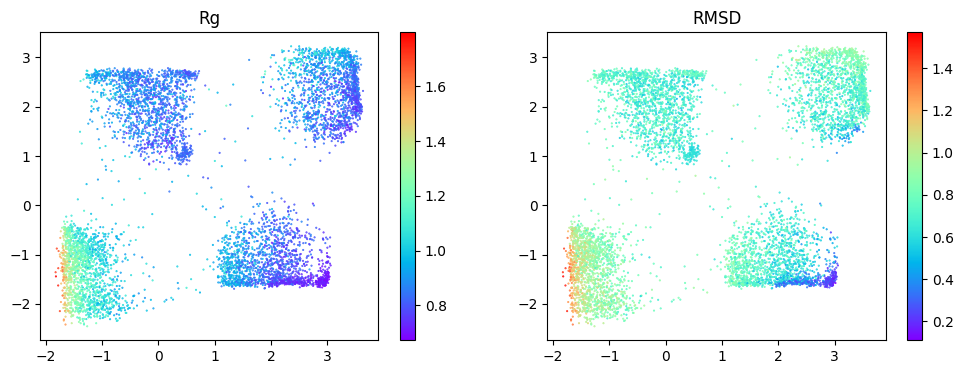

In [27]:
conf = '../trpcage 1.pdb'
tr = md.load('../xtc/x_test.xtc',top=conf)
device = next(m.parameters()).device
X_test_torch = torch.from_numpy(X_test_np).float().to(device)

with torch.no_grad():
    rec, y, z, lows = m(X_test_torch)

lows = lows.cpu().numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
tr.xyz.shape

In [ ]:
X_test_np.shape

In [ ]:
rg.shape, rmsd.shape

In [ ]:
lows.shape

In [ ]:
heads = m.heads(tf.linalg.diag(tf.constant([1.] * n_classes))).numpy()
y = m.enc(X_test_np)[0].numpy()
cl_size = np.sum(np.abs(y),axis=0)
c = np.log(1e-8+cl_size)
plt.scatter(heads[:,0],heads[:,1],c=c,cmap='magma')
plt.colorbar()
plt.show()

In [ ]:
cl_size, np.sum(cl_size), X_test_np.shape[0]

In [ ]:
z = m.enc(X_test_np)[1].numpy()
plt.scatter(z[:,0],z[:,1])
plt.show()

In [ ]:
heads

In [ ]:
def clust_stats(val,y):
    # "sizes" of clusters: sum of probabilities a test set point belongs to the category
    cl_size = np.sum(np.abs(y),axis=0)

    # mean value of each cluster: weight the values by the probabilities of belonging to the cluster, sum over clusters, and normalize with cluster "sizes"
    mean = (val @ y) / cl_size

    # variance of each cluster: squared difference from the mean, weighted by the probability, normalized
    var = np.sum(np.square((val.reshape((-1,1))-mean)) * y, axis=0) / cl_size

    return mean,var

In [ ]:
mean,s2=clust_stats(rmsd,y)
std = np.sqrt(s2)/mean
std, np.mean(std)

In [ ]:
mean,s2 = clust_stats(rg,y)
std = np.sqrt(s2)/mean
std, np.mean(std)

with best_disc_seed=32

rmsd:
(array([0.14352965, 0.20439424, 0.20825054, 0.33096504], dtype=float32), 0.22178486)

rg:
(array([0.08874252, 0.17166458, 0.18333455, 0.08933956]), 0.133270302660158)


In [ ]:
len(m.get_weights())

In [ ]:
len(m.enc.get_weights()),len(m.dec.get_weights()),len(m.sum.get_weights()),len(m.y_disc.get_weights()),len(m.z_disc.get_weights())

In [ ]:
m.summary()